In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

def uniform_field_kolmo(M_A, Bz_true, angle_range, g_size, plotting=False):
    """
    ISM toy polarization model with LOS turbulence parameterized
    by Alfvénic Mach number M_A.
    """

    # ------------------------------------------------------------------
    # PARAMETERS
    # ------------------------------------------------------------------
    sigma_phi = M_A
    I0 = 1.0
    Bx0, By0 = 1.0, 1.0
    angle_range = np.linspace(angle_range[0], angle_range[1], g_size)

    # =========================
    # GRID
    # =========================
    x = np.linspace(-np.pi, np.pi, g_size)
    y = np.linspace(-np.pi, np.pi, g_size)
    z = np.linspace(-np.pi, np.pi, g_size)
    X, Y, Z = np.meshgrid(x, y, z, indexing="xy")

    dx = x[1] - x[0]
    dy = y[1] - y[0]
    dz = z[1] - z[0]

    Bx = np.zeros_like(X)
    By = np.zeros_like(Y)
    Bz = np.zeros_like(Z)

    # =========================
    # LARGE-SCALE POS FIELD
    # =========================
    for iz in range(g_size):
        itheta = angle_range[iz]
        Bx[:, :, iz] = Bx0 * np.cos(itheta)
        By[:, :, iz] = By0 * np.sin(itheta)
        Bz[:, :, iz] = Bz_true

    # ------------------------------------------------------------------
    # 3D KOLMOGOROV TURBULENCE
    # ------------------------------------------------------------------
    kx = np.fft.fftfreq(g_size, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(g_size, d=dy) * 2 * np.pi
    kz = np.fft.fftfreq(g_size, d=dz) * 2 * np.pi
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="xy")

    k2 = KX**2 + KY**2 + KZ**2
    k  = np.sqrt(k2)

    # --- random complex Gaussian vector field (unit variance per mode) ---
    rng = np.random.default_rng()

    def rand_complex(shape):
        return (rng.standard_normal(shape) + 1j * rng.standard_normal(shape)) / np.sqrt(2)

    Fx = rand_complex(X.shape)
    Fy = rand_complex(X.shape)
    Fz = rand_complex(X.shape)

    # --- Kolmogorov amplitude weighting: |B_k| ∝ k^(-11/6) ---
    # Power spectrum E(k) ∝ k^(-11/3) in 3D  →  amplitude ∝ k^(-11/6)
    # Zero-mode is left at zero (no mean turbulent field).
    with np.errstate(divide="ignore", invalid="ignore"):
        kolmogorov_weight = np.where(k > 0, k ** (-11.0 / 6.0), 0.0)

    Fx *= kolmogorov_weight
    Fy *= kolmogorov_weight
    Fz *= kolmogorov_weight

    # --- Enforce Hermitian symmetry so IFFT is real ---
    # np.fft.ifftn handles this automatically as long as we don't break it;
    # taking .real after ifftn is sufficient for our purposes.

    # --- Project out compressive (longitudinal) component: F → F_perp ---
    # This guarantees ∇·δB = 0 in the continuous sense.
    k2_safe = np.where(k2 > 0, k2, 1.0)   # avoid divide-by-zero at k=0

    k_dot_F = KX * Fx + KY * Fy + KZ * Fz

    Fx -= KX * k_dot_F / k2_safe
    Fy -= KY * k_dot_F / k2_safe
    Fz -= KZ * k_dot_F / k2_safe

    # --- Back to real space ---
    dBx = np.fft.ifftn(Fx).real
    dBy = np.fft.ifftn(Fy).real
    dBz = np.fft.ifftn(Fz).real

    # --- Normalise so that rms(|δB|) = M_A ---
    rms = np.sqrt(np.mean(dBx**2 + dBy**2 + dBz**2))
    if rms > 0:
        dBx *= M_A / rms
        dBy *= M_A / rms
        dBz *= M_A / rms

    # --- Add turbulence to large-scale field ---
    Bx += dBx
    By += dBy
    Bz += dBz

    # ------------------------------------------------------------------
    # ENFORCE DIVERGENCE-FREE CONDITION ON FULL FIELD
    # Project out the longitudinal part of the total field in Fourier space.
    # ------------------------------------------------------------------
    Bx_k = np.fft.fftn(Bx)
    By_k = np.fft.fftn(By)
    Bz_k = np.fft.fftn(Bz)

    k_dot_B = KX * Bx_k + KY * By_k + KZ * Bz_k

    mask = k2 > 0
    Bx_k[mask] -= KX[mask] * k_dot_B[mask] / k2[mask]
    By_k[mask] -= KY[mask] * k_dot_B[mask] / k2[mask]
    Bz_k[mask] -= KZ[mask] * k_dot_B[mask] / k2[mask]

    Bx = np.fft.ifftn(Bx_k).real
    By = np.fft.ifftn(By_k).real
    Bz = np.fft.ifftn(Bz_k).real

    # =========================
    # OPTIONAL FIELD PLOTTING
    # =========================
    if plotting:
        fig, ax = plt.subplots(1, g_size, figsize=(18, 2))
        for iz in range(g_size):
            ax[iz].quiver(
                X[:, :, iz], Y[:, :, iz],
                Bx[:, :, iz], By[:, :, iz],
                pivot="middle",
                scale=2,
                scale_units="xy",
                headlength=0,
                headaxislength=0
            )
            ax[iz].set_title(f"z={iz}")
        plt.tight_layout()
        plt.show()

    # =========================
    # STOKES FROM FIELD
    # =========================
    Bperp2 = Bx**2 + By**2
    Btot2 = Bperp2 + Bz**2 + 1e-12

    cos2g = Bperp2 / Btot2
    q = (By**2 - Bx**2) / Btot2
    u = (2 * Bx * By) / Btot2

    Q3 = I0 * q
    U3 = I0 * u

    # =========================
    # LOS INTEGRATION
    # =========================
    Q_obs = Q3.sum(axis=2)
    U_obs = U3.sum(axis=2)
    I_obs = I0 * g_size

    P_obs = np.sqrt(Q_obs**2 + U_obs**2) / I_obs
    phi_obs = 0.5 * np.arctan2(U_obs, Q_obs)
    cos2g_LOS = cos2g.mean(axis=2)

    return P_obs, phi_obs, cos2g_LOS


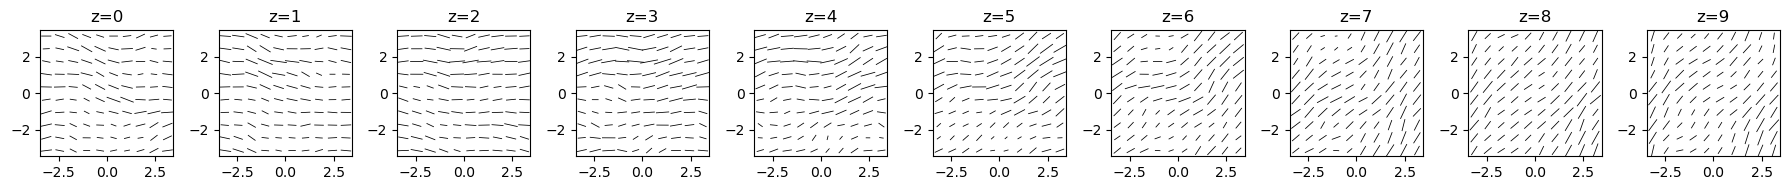

In [16]:
P, PHI, COS = uniform_field_kolmo(M_A=0.5, Bz_true=0, angle_range=[0,np.pi/4], g_size=10, plotting=True)

Text(0.5, 1.0, 'Wavy Field; divB=0, 3D turbulence')

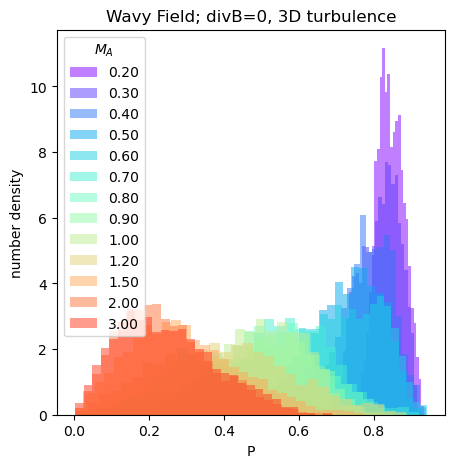

In [17]:
# mach_vals = [0.25,0.5,0.75,1,3]#np.linspace(0,2,4)
# mach_vals = np.linspace(0.2,1,10)
# mach_vals = [0.01,0.02, 0.03, 0.04, 0.05, 0.07, 0.1]
mach_vals = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.2,1.5,2,3]

plt.figure(figsize=(5,5))

for imach in mach_vals:
    P, PHI, C = uniform_field_kolmo(M_A=imach, Bz_true=0, angle_range=[0,np.pi/4], g_size=64, plotting=False)
    plt.hist(P.flatten(), bins=30, alpha=0.5, label=f"{imach:.2f}", density=True, color = plt.cm.rainbow(mach_vals.index(imach)/len(mach_vals)))
plt.xlabel("P")
plt.ylabel('number density')
plt.legend(title=r'$M_A$')
plt.title('Wavy Field; divB=0, 3D turbulence')
# plt.ylim(0,2000)

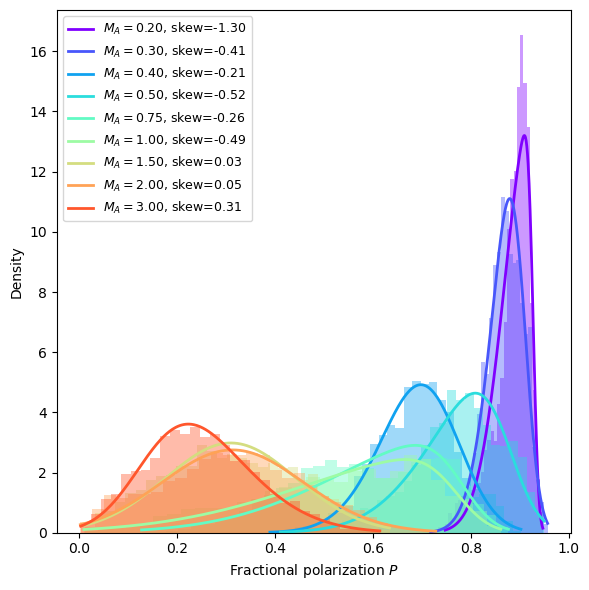

In [18]:
from scipy.stats import skew, skewnorm
plt.figure(figsize=(6, 6))
mach_vals = [0.2,0.3, 0.4, 0.5,0.75,1,1.5,2,3]
skews = []

for imach in mach_vals:

    # simulate
    P, PHI, C = uniform_field_kolmo(M_A=imach, Bz_true=0, angle_range=[0,np.pi/4], g_size=64, plotting=False)

    # flatten & clip to >0
    Pflat = P.flatten()
    Pflat = Pflat[Pflat > 0]

    # --- compute raw skewness ---
    skew_val = skew(Pflat, bias=False)
    skews.append(skew_val)

    # --- fit skewnormal distribution ---
    # skewnorm.fit returns (a, loc, scale)
    a, loc, scale = skewnorm.fit(Pflat)

    # build PDF for plotting
    x = np.linspace(Pflat.min(), Pflat.max(), 300)
    pdf_skew = skewnorm.pdf(x, a, loc=loc, scale=scale)

    # --- histogram ---
    plt.hist(Pflat, bins=30, density=True, alpha=0.4, color = plt.cm.rainbow(mach_vals.index(imach)/len(mach_vals)))

    # --- overlay skewnormal fit ---
    plt.plot(x, pdf_skew, lw=2, label=rf"$M_A={imach:.2f}$, skew={skew_val:.2f}", color = plt.cm.rainbow(mach_vals.index(imach)/len(mach_vals)))

plt.xlabel("Fractional polarization $P$")
plt.ylabel("Density")
# plt.yscale('log')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


/var/folders/q3/hykz569d1r1c51lc9dq_8cb00000gn/T/ipykernel_12876/2683032699.py:9: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skews.append(skew(P.flatten(), bias=False))


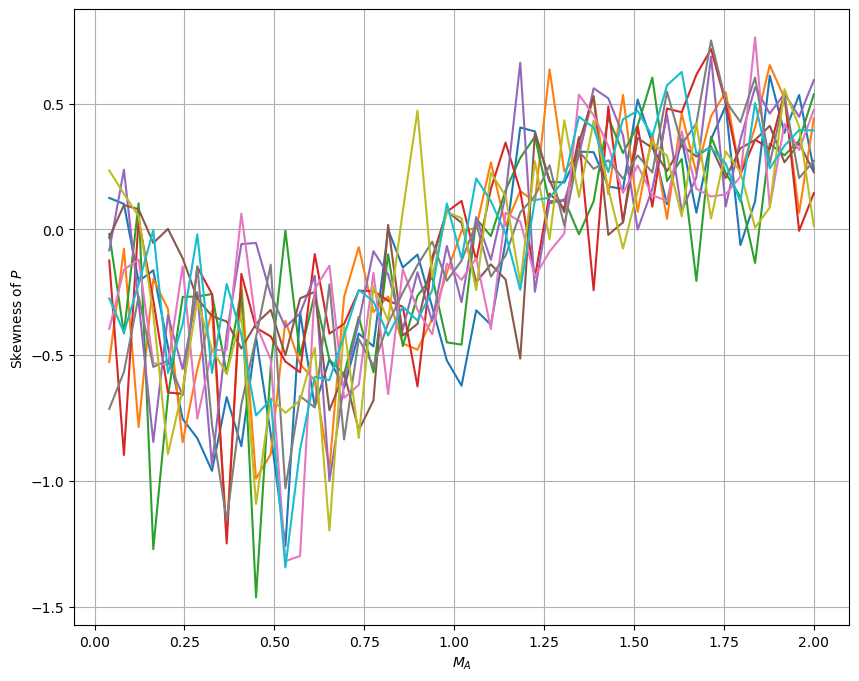

In [19]:
plt.figure(figsize=(10, 8))
n = 10
for i in range(n):
    skews = []
    mach_vals = np.linspace(0,2,50)
    # mach_vals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0,3.5,4,4.5,5]
    for imach in mach_vals:
        P, PHI, C = uniform_field_kolmo(M_A=imach, Bz_true=0, angle_range=[0,np.pi/4], g_size=64, plotting=False)
        skews.append(skew(P.flatten(), bias=False))

    plt.plot(mach_vals, skews, linestyle='-')
    
plt.xlabel(r"$M_A$")
plt.ylabel("Skewness of $P$")
plt.grid(True)
plt.show()